## Assignment 2: Neural Machine Translation

In this assignment, we will implement an encoder-decoder neural network for the task of machine translation.

![img](https://lena-voita.github.io/resources/lectures/seq2seq/general/enc_dec_simple_rnn-min.png)

We'll translate short image descriptions (without using the images themselves) from English to German. 
This task shows the scale of machine translation while not requiring you to train your model for weeks if you don't use GPU.

## Setup

In [3]:
# install dependencies
!pip3 install torch pandas nltk matplotlib
!pip3 install subword-nmt &> log
!pip3 install huggingface-hub
!wget "https://gist.githubusercontent.com/saparina/45e4e8af5cb6b57c786ca246e1c75530/raw/b7d06c8a570b68ef22c9fc2f627bbb8a54f4cf27/vocab.py"

--2026-03-02 23:47:53--  https://gist.githubusercontent.com/saparina/45e4e8af5cb6b57c786ca246e1c75530/raw/b7d06c8a570b68ef22c9fc2f627bbb8a54f4cf27/vocab.py
Resolving gist.githubusercontent.com (gist.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to gist.githubusercontent.com (gist.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2878 (2.8K) [text/plain]
Saving to: ‘vocab.py.2’

vocab.py.2          100%[===================>]   2.81K  --.-KB/s    in 0s      

2026-03-02 23:47:54 (39.8 MB/s) - ‘vocab.py.2’ saved [2878/2878]



In [4]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline

In [5]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [7]:
source_lang = "en"
target_lang = "de"
splits = ['train', 'val', 'test']

data = {}
for split in splits:
    file_name = f"{split}.jsonl"
    df = pd.read_json(f"hf://datasets/bentrevett/multi30k/{file_name}", lines=True)
    data[split] = df

for split, df in data.items():
    df['de'].to_csv(f"{split}.de", index=False, header=False, mode='w')
    df['en'].to_csv(f"{split}.en", index=False, header=False, mode='w')

/home/switch/tmp/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Preprocessing (5 points)

Before we get to the architecture, it is important to preprocess the data. For this assignment, the preprocessing has already been done for you. 

Here's the process:
1. The data is tokenized with [WordPunctTokenizer](https://www.nltk.org/api/nltk.tokenize.regexp.html#nltk.tokenize.regexp.WordPunctTokenizer)  which splits text based on word boundaries and punctuation.

2. Then we apply [Byte Pair Encoding](https://github.com/rsennrich/subword-nmt). The algorithm starts with a character-level tokenization and then iteratively merges most frequent pairs for N iterations. This results in frequent words being merged into a single token and rare words split into syllables or even characters.



In [8]:
from nltk.tokenize import WordPunctTokenizer
from subword_nmt.learn_bpe import learn_bpe
from subword_nmt.apply_bpe import BPE
tokenizer = WordPunctTokenizer()
def tokenize(x):
    return ' '.join(tokenizer.tokenize(x.lower()))

# split and tokenize the data
for lang in [source_lang, target_lang]:
    for split in splits:
        with open(split + '.tok.' + lang, 'w') as f_src:
            for line in open(split + '.' + lang):
                f_src.write(tokenize(line) + '\n')

# build and apply bpe vocs
bpe = {}
for lang in [source_lang, target_lang]:
    learn_bpe(open('./train.tok.' + lang), open('bpe_rules.' + lang, 'w'), num_symbols=8000)
    bpe[lang] = BPE(open('./bpe_rules.' + lang))

    for split in splits:
        with open(split + '.bpe.' + lang, 'w') as f_out:
            for line in open(split + '.tok.' + lang):
                f_out.write(bpe[lang].process_line(line.strip()) + '\n')

 62%|██████▏   | 4938/8000 [00:01<00:00, 3554.03it/s]

100%|██████████| 8000/8000 [00:03<00:00, 2076.91it/s]


### Building vocabularies

We now need to build vocabularies that map strings to token ids and vice versa. We're will use them when we feed training data into model or convert output matrices into words.

In [9]:
train_inp = np.array(open('train.bpe.' + source_lang, encoding='utf-8').read().split('\n'))
train_out = np.array(open('train.bpe.' + target_lang, encoding='utf-8').read().split('\n'))

val_inp   = np.array(open('val.bpe.' + source_lang, encoding='utf-8').read().split('\n'))
val_out   = np.array(open('val.bpe.' + target_lang, encoding='utf-8').read().split('\n'))

test_inp = np.array(open('test.bpe.' + source_lang, encoding='utf-8').read().split('\n'))
test_out = np.array(open('test.bpe.' + target_lang, encoding='utf-8').read().split('\n')) # UPDATE 2025-02-26: Previous version incorrectly computed test BLEU score, now fixed

print(len(train_inp))
print(len(train_out))
print(len(val_inp))
print(len(val_out))
print(len(test_inp))
print(len(test_out))
for i in range(3):
    print('inp:', train_inp[i])
    print('out:', train_out[i], end='\n\n')

29001
29001
1015
1015
1001
1001
inp: " two young , white males are outside near many bushes ."
out: zwei junge weiße männer sind im freien in der nähe viel@@ er büsche .

inp: several men in hard hats are operating a giant pulley system .
out: mehrere männer mit schutzhelmen bedienen ein an@@ tri@@ eb@@ s@@ rad@@ system .

inp: a little girl climbing into a wooden playhouse .
out: ein kleines mädchen klettert in ein spiel@@ haus aus holz .



In [10]:
from vocab import Vocab
inp_voc = Vocab.from_lines(train_inp)
out_voc = Vocab.from_lines(train_out)

print("Source vocab size", len(inp_voc))
print("Target vocab size", len(out_voc))

Source vocab size 7202
Target vocab size 7679


In [11]:
# Here's how you cast lines into ids and backwards.
batch_lines = sorted(train_inp, key=len)[5:10]
batch_ids = inp_voc.to_matrix(batch_lines)
batch_lines_restored = inp_voc.to_lines(batch_ids)

print("lines")
print(batch_lines)
print("\nwords to ids (0 = bos, 1 = eos):")
print(batch_ids)
print("\nback to words")
print(batch_lines_restored)

lines
[np.str_('men play baseball .'), np.str_('a child in a swing .'), np.str_('a man playing cricket'), np.str_('a car is in the water'), np.str_('a man climbs a rock .')]

words to ids (0 = bos, 1 = eos):
tensor([[   0, 3659, 4416,  544,   22,    1,    1,    1],
        [   0,   65, 1166, 2969,   65, 6002,   22,    1],
        [   0,   65, 3568, 4424, 1513,    1,    1,    1],
        [   0,   65, 1010, 3065, 2969, 6186, 6902,    1],
        [   0,   65, 3568, 1255,   65, 4901,   22,    1]])

back to words
['men play baseball .', 'a child in a swing .', 'a man playing cricket', 'a car is in the water', 'a man climbs a rock .']


Draw source and translation length distributions to estimate the scope of the task.

(array([4.000e+00, 1.400e+01, 1.526e+03, 3.790e+03, 8.059e+03, 4.589e+03,
        5.100e+03, 2.188e+03, 1.929e+03, 7.210e+02, 4.480e+02, 3.430e+02,
        1.220e+02, 8.900e+01, 3.200e+01, 2.400e+01, 9.000e+00, 8.000e+00,
        2.000e+00, 4.000e+00]),
 array([ 0.  ,  2.45,  4.9 ,  7.35,  9.8 , 12.25, 14.7 , 17.15, 19.6 ,
        22.05, 24.5 , 26.95, 29.4 , 31.85, 34.3 , 36.75, 39.2 , 41.65,
        44.1 , 46.55, 49.  ]),
 <BarContainer object of 20 artists>)

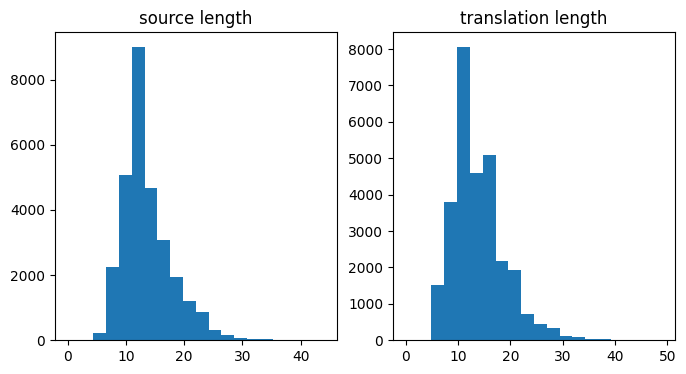

In [12]:
plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.title("source length")
plt.hist(list(map(len, map(str.split, train_inp))), bins=20)

plt.subplot(1, 2, 2)
plt.title("translation length")
plt.hist(list(map(len, map(str.split, train_out))), bins=20)

### ❓ Question (3 points)

What tokens correspond to indices 0 and 1 in vocabulary? What roles do they play in the probabilistic model that you will implement? Is it possible to train a model without them, and if so, how?

*<Your answer in 3-5 sentences>*

### ❓ Question (2 points)

Look at the BPE tokenised English and/ or German sentences (you may use Google translate for German). What are two things that you observe about the subword tokenisations that you see there? Illustrate your point(s) using examples.

*<Your answer in 3-5 sentences>*

## 2. Basic Encoder-Decoder Model (15 points)

The code below contains a template for a simple encoder-decoder model: single GRU encoder/decoder, no attention or anything. You need to implement ```decode_step``` (5 points).

In [13]:
class BasicModel(nn.Module):
    def __init__(self, inp_voc, out_voc, emb_size=64, hid_size=128):
        """
        A simple encoder-decoder seq2seq model
        """
        super().__init__() # initialize base class to track sub-layers, parameters, etc.

        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        self.emb_inp = nn.Embedding(len(inp_voc), emb_size)
        self.emb_out = nn.Embedding(len(out_voc), emb_size)
        self.enc0 = nn.GRU(emb_size, hid_size, batch_first=True)

        self.dec_start = nn.Linear(hid_size, hid_size)
        self.dec0 = nn.GRUCell(emb_size, hid_size)
        self.logits = nn.Linear(hid_size, len(out_voc))

    def forward(self, inp, out):
        """ Apply model in training mode """
        initial_state = self.encode(inp)
        return self.decode(initial_state, out)


    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :returns: initial decoder state tensors, one or many
        """
        # compute embeddings
        inp_emb = self.emb_inp(inp)
        batch_size = inp.shape[0]

        # sequentially applying a GRU cell to each input 
        # (this logic is hidden in the GRU implementation)
        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]

        # note: enc0 works on a batch level, so we will need to process padding!
        # last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        # create an initial hidden vector for the decoder
        dec_start = self.dec_start(last_state)
        return [dec_start]

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors, same as returned by encode(...)
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, len(out_voc)]
        """
        prev_gru0_state = prev_state[0]

        ### YOUR CODE
        # Get embedding of previous tokens. Shape: [batch_size, emb_size]
        prev_emb = self.emb_out(prev_tokens)
        
        # Apply decoder RNN cell. Shape: [batch_size, hid_size]
        new_dec_state = self.dec0(prev_emb, prev_gru0_state)
        
        # Get logits. Shape: [batch_size, len(out_voc)]
        output_logits = self.logits(new_dec_state)
        ### END OF YOUR CODE

        return [new_dec_state], output_logits 

    def decode(self, initial_state, out_tokens, **flags):
        """ Iterate over reference tokens (out_tokens) with decode_step, use for training"""
        batch_size = out_tokens.shape[0]
        state = initial_state

        # initial logits: always predict BOS
        onehot_bos = F.one_hot(torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64),
                               num_classes=len(self.out_voc)).to(device=out_tokens.device)
        first_logits = torch.log(onehot_bos.to(torch.float32) + 1e-9)

        logits_sequence = [first_logits]
        for i in range(out_tokens.shape[1] - 1):
            # note: we use the reference labels here (out_tokens)
            state, logits = self.decode_step(state, out_tokens[:, i])
            logits_sequence.append(logits)
        return torch.stack(logits_sequence, dim=1)

    def decode_inference(self, initial_state, max_len=100, **flags):
        """ Generate translations from model (greedy version), use for inference """
        batch_size, device = len(initial_state[0]), initial_state[0].device
        state = initial_state
        outputs = [torch.full([batch_size], self.out_voc.bos_ix, dtype=torch.int64,
                              device=device)]
        all_states = [initial_state]

        for i in range(max_len):
            # note: we use the predicted tokens
            state, logits = self.decode_step(state, outputs[-1])
            outputs.append(logits.argmax(dim=-1))
            all_states.append(state)

        return torch.stack(outputs, dim=1), all_states

    def translate_lines(self, inp_lines, **kwargs):
        inp = self.inp_voc.to_matrix(inp_lines).to(device)
        initial_state = self.encode(inp)
        out_ids, states = self.decode_inference(initial_state, **kwargs)
        return self.out_voc.to_lines(out_ids.cpu().numpy()), states

In [14]:
# debugging area
model = BasicModel(inp_voc, out_voc).to(device)

dummy_inp_tokens = inp_voc.to_matrix(sorted(train_inp, key=len)[5:10]).to(device)
dummy_out_tokens = out_voc.to_matrix(sorted(train_out, key=len)[5:10]).to(device)

h0 = model.encode(dummy_inp_tokens)
h1, logits1 = model.decode_step(h0, torch.arange(len(dummy_inp_tokens), device=device))

assert isinstance(h1, list), type(h1)
assert len(h1) == len(h0)
assert h1[0].shape == h0[0].shape and not torch.allclose(h1[0], h0[0])
assert logits1.shape == (len(dummy_inp_tokens), len(out_voc))

logits_seq = model.decode(h0, dummy_out_tokens)
assert logits_seq.shape == (dummy_out_tokens.shape[0], dummy_out_tokens.shape[1], len(out_voc))

# full forward
logits_seq2 = model(dummy_inp_tokens, dummy_out_tokens)
assert logits_seq2.shape == logits_seq.shape

In [15]:
dummy_translations, dummy_states = model.translate_lines(train_inp[:3], max_len=25)
print("Translations without training:")
print('\n'.join([line for line in dummy_translations]))

Translations without training:
afri@@ fußgängerbrücke teenagerin musku@@ football@@ pfeil orche@@ stie@@ y lackiert lackiert pre@@ afroamerikan@@ dribbelt stellt tzt winterjacke sportlerin ron stift aufhat trainieren etwas schrif@@ gür@@
afri@@ tte richter richter repariert vorbei ” suchen haltung verkehrt ara@@ trüben alls spielend akkordeon@@ packen steu@@ noti@@ lö@@ pustet übung neben@@ coca ehnt promenade
afri@@ wildwasser@@ 8@@ schleife rennt schnau@@ telef@@ telef@@ gegend hier ganzen oberteilen felsbrocken tro@@ handschuhe lächelndes 4@@ hemd@@ anzüge babyschaukel unterhaltung kreide koch@@ tanzfläche skolben


### Training loss (5 points)

Our training objective is:
$$ L = {\frac1{|D|}} \sum_{X, Y \in D} \sum_{y_t \in Y} - \log p(y_t \mid y_1, \dots, y_{t-1}, X, \theta) $$

where $|D|$ is the __total length of all sequences__, including BOS and first EOS, but excluding PAD.

In [16]:
import torch.nn.functional as F

def compute_loss(model, inp, out, **flags):
    """
    Compute loss (float32 scalar) as in the formula above
    :param inp: input tokens matrix, int32[batch, time]
    :param out: reference tokens matrix, int32[batch, time]

    In order to pass the tests, your function should
    * include loss at first EOS but not the subsequent ones
    * divide sum of losses by a sum of input lengths (use voc.compute_mask)
    """
    mask = model.out_voc.compute_mask(out) # [batch_size, out_len]
    targets_1hot = F.one_hot(out, len(model.out_voc)).to(torch.float32)

    # outputs of the model, [batch_size, out_len, num_tokens]
    ### YOUR CODE
    logits = model(inp, out)
    ### END OF YOUR CODE

    # log-probabilities of all tokens at all steps, [batch_size, out_len, num_tokens]
    ### YOUR CODE
    log_probs = F.log_softmax(logits, dim=-1)
    ### END OF YOUR CODE

    # log-probabilities of correct outputs, [batch_size, out_len]
    ### YOUR CODE
    # Element-wise multiplication selects the log-prob of the correct token
    log_probs_correct = (log_probs * targets_1hot).sum(dim=-1)
    ### END OF YOUR CODE
    # ^-- this will select the probability of the actual next token.

    # average cross-entropy over tokens where mask == True
    ### YOUR CODE
    # Multiply by mask to ignore padding tokens
    masked_log_probs = log_probs_correct * mask.to(torch.float32) 
    
    # Negative sum of log probs divided by the total number of valid tokens
    loss = -masked_log_probs.sum() / mask.sum()
    ### END OF YOUR CODE
    
    return loss

In [17]:
dummy_loss = compute_loss(model, dummy_inp_tokens, dummy_out_tokens)
print("Loss:", dummy_loss)
assert np.allclose(dummy_loss.item(), 7.6, rtol=0.01, atol=0.01), "We're sorry for your loss"

# test autograd
dummy_loss.backward()
for name, param in model.named_parameters():
    assert param.grad is not None and abs(param.grad.max()) != 0, f"Param {name} received no gradients"

print("Test passed!")

Loss: tensor(7.6071, device='cuda:0', grad_fn=<DivBackward0>)
Test passed!


### Evaluation: BLEU

Machine translation is commonly evaluated with [BLEU](https://en.wikipedia.org/wiki/BLEU) score. This metric simply computes which fraction of predicted n-grams is actually present in the reference translation. It does so for n=1,2,3 and 4 and computes the geometric average with penalty if translation is shorter than reference.

In [18]:
from nltk.translate.bleu_score import corpus_bleu
def compute_bleu(model, inp_lines, out_lines, bpe_sep='@@ ', **flags):
    """
    Estimates corpora-level BLEU score of model's translations given inp and reference out
    Note: if you're serious about reporting your results, use https://pypi.org/project/sacrebleu
    """
    with torch.no_grad():
        translations, _ = model.translate_lines(inp_lines, **flags)
        translations = [line.replace(bpe_sep, '') for line in translations]
        actual = [line.replace(bpe_sep, '') for line in out_lines]
        return corpus_bleu(
            [[ref.split()] for ref in actual],
            [trans.split() for trans in translations],
            smoothing_function=lambda precisions, **kw: [p + 1.0 / p.denominator for p in precisions]
            ) * 100

In [19]:
compute_bleu(model, val_inp, val_out)

0.004044872108229374

### Training loop (2+3 points)

Training encoder-decoder models isn't that different from any other models: sample batches, compute loss, backprop and update

In [20]:
from IPython.display import clear_output
from tqdm import tqdm, trange

model = BasicModel(inp_voc, out_voc).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

In [21]:
print("Model size", sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6, "M")

Model size 2.108479 M


Implement training loop (2 points):

In [1]:
def train(model, opt, batch_size, num_steps=20000, save_path="best_basemodel.pth"):
    metrics = {'train_loss': [], 'dev_bleu': [] }
    best_bleu = 0.0
    for _ in trange(num_steps):
        step = len(metrics['train_loss']) + 1
        batch_ix = np.random.randint(len(train_inp), size=batch_size)
        batch_inp = inp_voc.to_matrix(train_inp[batch_ix]).to(device)
        batch_out = out_voc.to_matrix(train_out[batch_ix]).to(device)

        ### YOUR CODE
        # 1. Compute the loss using our custom function
        loss_t = compute_loss(model, batch_inp, batch_out)
        
        # 2. Clear out the gradients from the previous step
        opt.zero_grad()
        
        # 3. Compute gradients for all model parameters (backpropagation)
        loss_t.backward()
        
        # 4. Update the parameters using the optimizer
        opt.step()
        ### END OF YOUR CODE

        metrics['train_loss'].append((step, loss_t.item()))

        if step % 100 == 0:
            dev_bleu = compute_bleu(model, val_inp, val_out)
            metrics['dev_bleu'].append((step, dev_bleu))

            if dev_bleu > best_bleu:
                best_bleu = dev_bleu
                torch.save(model.state_dict(), save_path)

            clear_output(True)
            plt.figure(figsize=(12,4))
            for i, (name, history) in enumerate(sorted(metrics.items())):
                plt.subplot(1, len(metrics), i + 1)
                plt.title(name)
                plt.plot(*zip(*history))
                plt.grid()
            plt.show()
            print("Mean loss=%.3f" % np.mean(metrics['train_loss'][-10:], axis=0)[1], flush=True)
    return metrics

Train your model (3 points):

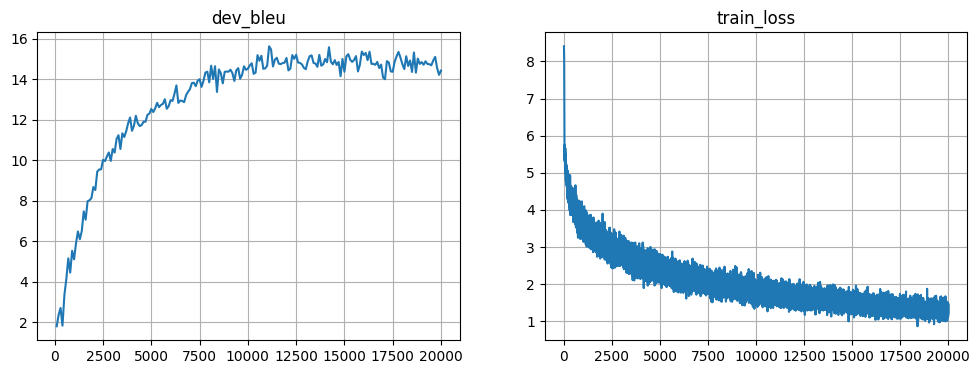

Mean loss=1.322


100%|██████████| 20000/20000 [11:29<00:00, 29.00it/s]


In [20]:
metrics = train(model, opt, batch_size)
# Note: it's okay if bleu oscillates up and down as long as it gets better on average over long term (e.g. 5k batches)

In [21]:
bleu_scores = np.mean(metrics['dev_bleu'][-10:], axis=0)[1]
assert bleu_scores > 13, f"BLEU score should be > 13 on average, you got {bleu_scores}"

In [22]:
model.load_state_dict(torch.load("best_basemodel.pth", weights_only=True))
model.to(device)

final_bleu_score = compute_bleu(model, test_inp, test_out)  # UPDATE 2025-02-26: Previous version incorrectly computed test BLEU score, now fixed
f"BLEU score on the test set: {final_bleu_score:.3}"

'BLEU score on the test set: 14.3'

## 3. Encoder-Decoder Model with Attention (15 points)

In this section we want you to improve over the basic model by implementing a simple attention mechanism.

This is gonna be a two-parter: building the __attention layer__ and using it for an __attentive seq2seq model__.

### Attention layer (6 points)

Here you will have to implement a layer that computes a simple additive attention:

Given encoder sequence $ h^e_0, h^e_1, h^e_2, ..., h^e_T$ and a single decoder state $h^d$,

* Compute scores with a 2-layer neural network:
$$s_t = \operatorname{linear}_{out}(\tanh(\operatorname{linear}_{enc}(h^e_t) + \operatorname{linear}_{dec}(h^d)))$$
* Get probabilities from scores:
$$ p_t = {{e ^ {s_t}} \over { \sum_\tau e^{s_\tau} }} $$

* Add up encoder states with probabilities to get __attention response__ (attention context vector):
$$ c = \sum_t p_t \cdot h^e_t $$

In [22]:
class AttentionLayer(nn.Module):
    def __init__(self, name, enc_size, dec_size, hid_size, activ=torch.tanh):
        """ A layer that computes additive attention response and weights """
        super().__init__()
        self.name = name
        self.enc_size = enc_size # num units in encoder state
        self.dec_size = dec_size # num units in decoder state
        self.hid_size = hid_size # attention layer hidden units
        self.activ = activ       # attention layer hidden nonlinearity

        # create trainable paramteres
        self.linear_enc = nn.Parameter(torch.zeros(self.enc_size, self.hid_size), requires_grad=True)
        self.linear_dec = nn.Parameter(torch.zeros(self.dec_size, self.hid_size), requires_grad=True) # you will need a couple of these
        self.linear_out = nn.Parameter(torch.zeros(self.hid_size, 1), requires_grad=True)

        torch.nn.init.xavier_uniform_(self.linear_enc.data)
        torch.nn.init.xavier_uniform_(self.linear_dec.data)
        torch.nn.init.xavier_uniform_(self.linear_out.data)


    def forward(self, enc, dec, inp_mask):
        """
        Computes attention response and weights
        :param enc: encoder activation sequence, float32[batch_size, ninp, enc_size]
        :param dec: single decoder state used as "query", float32[batch_size, dec_size]
        :param inp_mask: mask on enc activatons (0 after first eos), float32 [batch_size, ninp]
        :returns: attn[batch_size, enc_size], probs[batch_size, ninp]
            - attn - attention response vector (weighted sum of enc)
            - probs - attention weights after softmax
        """
        # Compute scores
        ### YOUR CODE
        # Project encoder states: [batch_size, ninp, hid_size]
        enc_proj = torch.matmul(enc, self.linear_enc)
        
        # Project decoder state: [batch_size, hid_size]
        dec_proj = torch.matmul(dec, self.linear_dec)
        
        # Add projections (broadcasting dec_proj across the sequence dimension) and apply activation
        hidden = self.activ(enc_proj + dec_proj.unsqueeze(1))
        
        # Project to a single score per token: [batch_size, ninp, 1] -> [batch_size, ninp]
        scores = torch.matmul(hidden, self.linear_out).squeeze(-1)
        ### END OF YOUR CODE

        # Apply mask - if mask is 0, scores should be -inf or -1e9
        # You may need torch.where
        ### YOUR CODE
        scores = torch.where(inp_mask == 0, torch.full_like(scores, -1e9), scores)
        ### END OF YOUR CODE

        # Compute attention probabilities (softmax)
        ### YOUR CODE
        probs = torch.softmax(scores, dim=-1)
        ### END OF YOUR CODE

        # Compute attention response using enc and probs
        ### YOUR CODE
        # Expand probs to [batch_size, ninp, 1] so it can broadcast over enc_size during multiplication,
        # then sum over the sequence length (dim=1) to get the context vector.
        attn = torch.sum(probs.unsqueeze(-1) * enc, dim=1)
        ### END OF YOUR CODE

        return attn, probs

In [23]:
# debugging
batch_size = 32
ninp = 7
enc_size = 64
dec_size = 128
layer = AttentionLayer("", enc_size, dec_size, 72)
attn, probs = layer(torch.rand(batch_size, ninp, enc_size), torch.rand(batch_size, dec_size), torch.rand(batch_size, ninp) > .5)
assert attn.shape == (batch_size, enc_size), attn.shape
assert probs.shape == (batch_size, ninp), probs.shape # if you have redundant dimensions of size 1, you might find torch.squeeze useful

### Seq2seq model with attention (6 points)

You can now use the attention layer to build a network. The simplest way to implement attention is to use it in decoder phase:
![img](https://lena-voita.github.io/resources/lectures/seq2seq/attention/bahdanau_model-min.png)

- On every step, use __previous__ decoder state to obtain attention response. 
- Then feed concat this response to the inputs of next attention layer.

The key implementation detail here is __model state__. Any tensor added into the list of `encode` outputs list will be available for use during each `decode` step. You should include:
* Last RNN hidden states (as in basic model)
* The whole sequence of encoder outputs (to attend to) and mask
* Attention response and attention probabilities (to visualize)

In [26]:
class AttentiveModel(BasicModel):
    def __init__(self, name, inp_voc, out_voc,
                 emb_size=64, hid_size=128, attn_size=128):
        """ Translation model that uses attention. Inherit all functions and params of BasicModel """
        self.inp_voc, self.out_voc = inp_voc, out_voc
        self.hid_size = hid_size

        super().__init__(inp_voc, out_voc, emb_size=emb_size, hid_size=hid_size)
        self.attention = AttentionLayer(name, hid_size, hid_size, attn_size)
        # Note the modified input size: emb_size + attn_size
        self.dec0 = nn.GRUCell(emb_size + attn_size, hid_size)

    def encode(self, inp, **flags):
        """
        Takes symbolic input sequence, computes initial state
        :param inp: matrix of input tokens [batch, time]
        :return: a list of initial decoder state tensors
        """
        # encode input sequence, create initial decoder states
        ### YOUR CODE
        inp_emb = self.emb_inp(inp)

        enc_seq, [last_state_but_not_really] = self.enc0(inp_emb)
        # enc_seq: [batch, time, hid_size], last_state: [batch, hid_size]
        ### END OF YOUR CODE

        # note: last_state is not _actually_ last because of padding, let's find the real last_state
        lengths = (inp != self.inp_voc.eos_ix).to(torch.int64).sum(dim=1).clamp_max(inp.shape[1] - 1)
        last_state = enc_seq[torch.arange(len(enc_seq)), lengths]
        # ^-- shape: [batch_size, hid_size]

        dec_start = self.dec_start(last_state)

        # apply attention layer from initial decoder hidden state
        inp_mask = self.inp_voc.compute_mask(inp)

        ### YOUR CODE
        first_attn_response, first_attn_probas = self.attention(enc_seq, dec_start, inp_mask)
        ### END OF YOUR CODE

        # Build first state: include
        # * initial states for decoder recurrent layers
        # * encoder sequence and encoder attn mask (for attention)
        # * make sure that last state item is attention probabilities tensor

        first_state = [dec_start, enc_seq, inp_mask, first_attn_response, first_attn_probas]
        return first_state

    def decode_step(self, prev_state, prev_tokens, **flags):
        """
        Takes previous decoder state and tokens, returns new state and logits for next tokens
        :param prev_state: a list of previous decoder state tensors
        :param prev_tokens: previous output tokens, an int vector of [batch_size]
        :return: a list of next decoder state tensors, a tensor of logits [batch, n_tokens]
        """
        prev_gru0_state, enc_seq, inp_mask, prev_attn_response, prev_attn_probas = prev_state

        ### YOUR CODE
        prev_tokens_emb = self.emb_out(prev_tokens)
        
        # Concatenate the previous token embedding with the previous attention context vector
        concat_inp = torch.cat([prev_tokens_emb, prev_attn_response], dim=-1)
        
        # Apply the GRU cell
        new_dec_state = self.dec0(concat_inp, prev_gru0_state)
        
        # Compute logits for the next token prediction
        output_logits = self.logits(new_dec_state)

        # Calculate attention context and probabilities for the *next* step
        attn_response, attn_probas = self.attention(enc_seq, new_dec_state, inp_mask)
        ### END OF YOUR CODE

        return [new_dec_state, enc_seq, inp_mask, attn_response, attn_probas], output_logits


### Training attentive model (3 points)

Please reuse the infrastructure you've built for the basic model.

In [27]:
metrics = {'train_loss': [], 'dev_bleu': [] }

model = AttentiveModel("model", inp_voc, out_voc, hid_size=128, attn_size=128).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 32

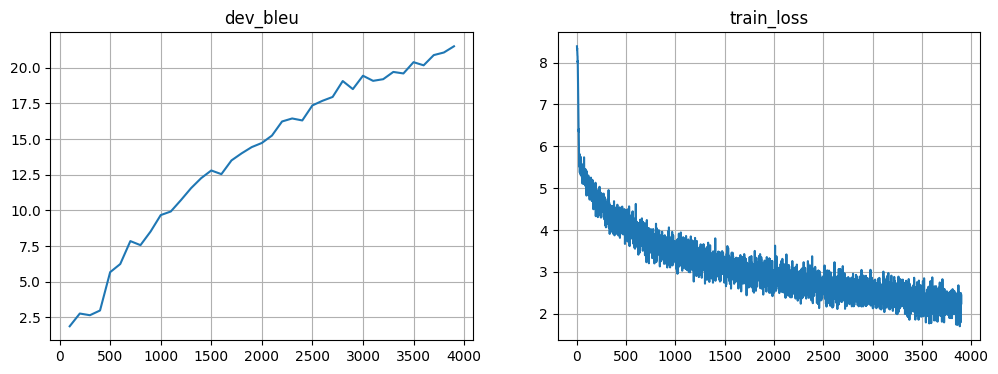

Mean loss=2.193


 20%|█▉        | 3955/20000 [03:06<12:37, 21.17it/s]


KeyboardInterrupt: 

In [28]:
metrics = train(model, opt, batch_size, save_path="best_attentivemodel.pth")

In [ ]:
model.load_state_dict(torch.load("best_attentivemodel.pth", weights_only=True))
model.to(device)

final_bleu_score = compute_bleu(model, test_inp, test_out)  # UPDATE 2025-02-26: Previous version incorrectly computed test BLEU score, now fixed
f"BLEU score on the test set: {final_bleu_score:.3}"

### ❓ Question

Compare the BLEU scores of the attentive model and the basic model you trained in the previous section. Which one performs better, and why?

*<Your answer in 1-3 sentences>*

## 4. Analyzing NMT (15 points)

### Translation Analysis (4 points)

Let's explore how the model we trained translates: 


In [34]:
for inp_line in test_inp[:5]:
    trans_lines, _ = model.translate_lines([inp_line])
    trans_line = trans_lines[0]
    print(inp_line)
    print(trans_line)
    print()

a man in an orange hat starring at something .
ein mann mit einem orangefarbenen hut verkauft etwas etwas .

a boston terrier is running on lush green grass in front of a white fence .
ein wanderer spielt auf einem weißen zaun auf einem weißen zaun .

a girl in karate uniform breaking a stick with a front kick .
ein mädchen in uniform fährt mit einem stock mit einem stock .

" five people wearing winter jackets and helmets stand in the snow , with snow@@ mobil@@ es in the background ."
" fünf personen in winterkleidung und mit helmen im schnee stehen im schnee , während im hintergrund sind bäume im hintergrund ."

people are fixing the roof of a house .
leute gehen auf dem dach eines hauses .



### ❓ Question (2 points)

Analyze the errors your model makes. You may use any external translator (e.g., Google Translate) to translate the German sentences back to English in order to better understand their meaning. Do you observe any patterns?

*<Your answer in 3-5 sentences>*

### ❓ Question (2 points)

What changes to the system do you think might improve these translations? Justify your answer.

*<Your answer in 3-4 sentences>*

### Visualising and analysing attention (6 points)

You can validate your model by visualizing its attention weights. We provided you with a function that draws attention maps. You will need to provide code to produce attention probabilities.

In [29]:
import matplotlib.pyplot as plt
import numpy as np

def draw_attention(inp_line, translation, probs):
    """ Visualize attention weights with a black background and white squares """
    # Tokenize input and translation
    inp_tokens = inp_voc.tokenize(inp_line)
    trans_tokens = out_voc.tokenize(translation)
    probs = probs[:len(trans_tokens), :len(inp_tokens)]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.set_facecolor("black")
    cax = ax.matshow(probs[::-1], cmap='gray')
    
    color_bar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(len(inp_tokens)))
    ax.set_xticklabels(inp_tokens, rotation=45, ha='left', rotation_mode='anchor')

    ax.set_yticks(np.arange(len(trans_tokens)))
    ax.set_yticklabels(trans_tokens[::-1])
    
    
    ax.tick_params(axis='both', which='both', length=0)  
    ax.spines[:].set_visible(False) 

    plt.show()

In [30]:
trans, states = model.translate_lines(test_inp[:5])

# select attention probs from model state
# attention_probs below must have shape [batch_size, translation_length, input_length], extracted from states
# e.g. if attention probs are at the end of each state, use np.stack([state[-1] for state in states], axis=1)

### YOUR CODE
attention_probs = torch.stack([state[-1] for state in states], dim=1).cpu().detach().numpy()
### END OF YOUR CODE

In [31]:
# Check for all examples and all translation steps
assert np.allclose(attention_probs.sum(axis=2), 1.0, atol=1e-4), "Attention probabilities do not sum to 1!"

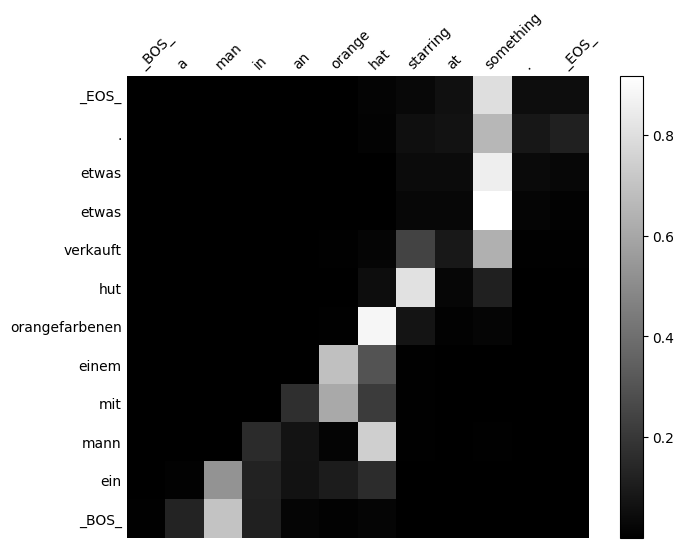

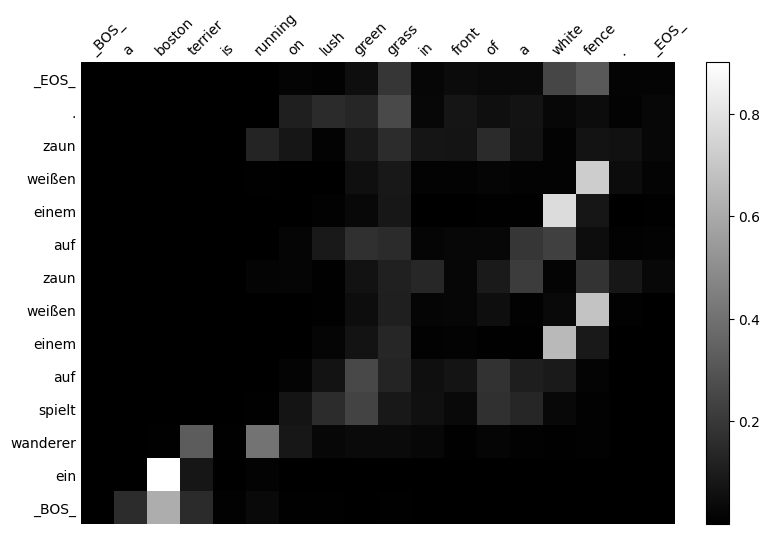

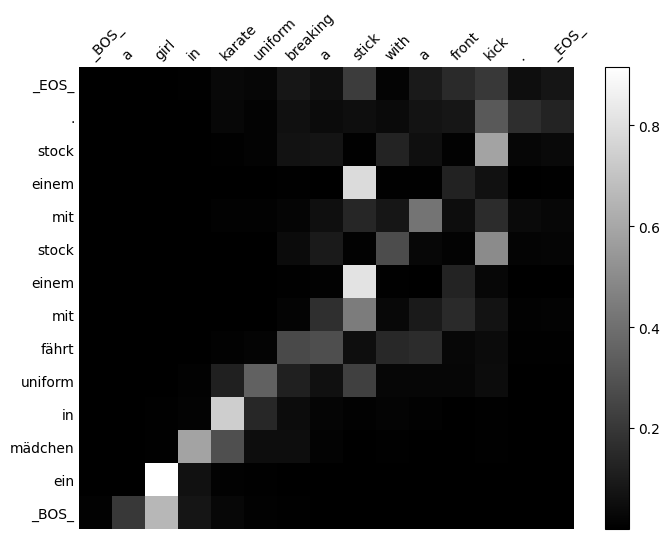

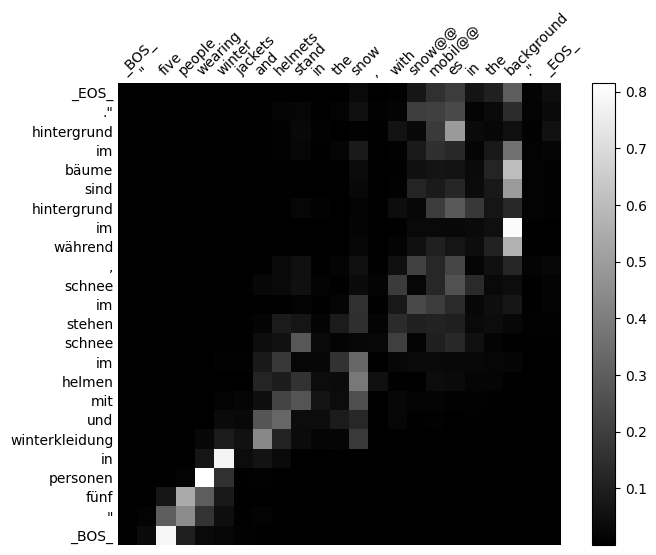

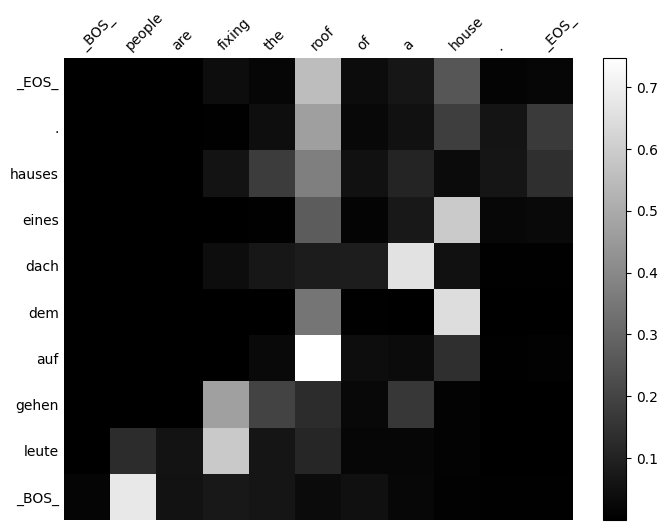

In [32]:
for i in range(5):
    draw_attention(test_inp[i], trans[i], attention_probs[i])
# Does it look fine already? don't forget to save images!

### ❓ Question (4 points)

Choose 2 of the translation errors you identified earlier and use the visualisation to explain how this attention pattern could have contributed to the error. Your explanation should make an explicit connection between what went wrong in the translation and what you see in the attention map.

*<Your answer in 5-7 sentences>*

### Finding patterns in attention  (5 points)

You probably have noticed that when visualizing attention maps, some cells have large attention weights. In this task, you will extract, summarize, and interpret high-attention source–target token pairs. To make sure the results are reliable, you should translate more sentences than the 5 used earlier.

Below we provide a function that allows you to extract all source–target token pairs and their attention weights. You will use it to analyse patterns of attention from your model.

In [33]:
def print_attention_weights_for_sentence(sentence, model, inp_voc, out_voc, threshold=0.7):
    """
    Given an input sentence, translates it using the model,
    then prints all source-token to target-token attention weights.
    """
    # Translate sentence and get states
    translation, states = model.translate_lines([sentence])
    # Get attention probabilities (shape: [1, translation_length, input_length])
    attention_probs = np.stack([state[-1].detach().cpu().numpy() for state in states], axis=1)
    # Remove the batch dimension for single sentence
    probs = attention_probs[0, :, :]
    inp_tokens = inp_voc.tokenize(sentence)
    trans_tokens = out_voc.tokenize(translation[0])
    # Match probabilities to the valid length (can be shorter due to eos)
    probs = probs[:len(trans_tokens), :len(inp_tokens)]
    print(f"Input: {sentence}")
    print(f"Translation: {translation[0]}")
    for out_idx, out_tok in enumerate(trans_tokens):
        for in_idx, in_tok in enumerate(inp_tokens):
            print(f"  {out_tok} <--{probs[out_idx, in_idx]:.2f}-- {in_tok}")

### ❓ Question  (3 points)

Consider pairs with attention weights greater than 0.7. Identify two recurring patterns (e.g., types of token pairs that frequently receive high attention). For each pattern, provide supporting examples and explain why you think this pattern produces high attention weights.

*<Your answer in 6-10 sentences>*

### ❓ Question  (2 points)

Repeat the extraction with a threshold of 0.9. Compare the results against the 0.7 case: which patterns decrease or disappear the most, and why? Support your answer with examples from both thresholds.

*<Your answer in 6-10 sentences>*